In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
# ====================== 多粒子 LJ 系统 + PBC ======================

def minimum_image_distance(r_vec, box_length):
    """最小镜像约定"""
    r_vec = r_vec - box_length * np.round(r_vec / box_length)
    return r_vec


def lj_potential(r, epsilon=1.0, sigma=1.0, r_cut=3.0):
    """Lennard-Jones 势能"""
    if r < 1e-8 or r > r_cut:
        return 0.0
    sr6 = (sigma / r) ** 6
    return 4 * epsilon * (sr6**2 - sr6)


def total_energy(positions, box_length, epsilon=1.0, sigma=1.0, r_cut=3.0):
    """使用 PBC + 最小镜像计算总势能"""
    N = positions.shape[0]
    energy = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            r_vec = positions[i] - positions[j]
            r_vec = minimum_image_distance(r_vec, box_length)
            r = np.linalg.norm(r_vec)
            energy += lj_potential(r, epsilon, sigma, r_cut)
    return energy


def apply_pbc(positions, box_length):
    """将粒子位置折叠回盒子内"""
    return positions % box_length


def proposal(positions, move_scale, box_length):
    """随机移动一个粒子"""
    new_positions = positions.copy()
    idx = np.random.randint(0, len(positions))
    displacement = np.random.normal(0, move_scale, size=3)
    new_positions[idx] += displacement
    new_positions = apply_pbc(new_positions, box_length)
    return new_positions

def write_gro_file(positions, box_length, filename="lj_config.gro", title="LJ MCMC Configuration, t= 0.0"):
    """
    将粒子构型输出为标准的 GROMACS .gro 文件
    """
    N = positions.shape[0]
    with open(filename, 'a') as f:
        # Title
        f.write(title + "\n")
        # Number of atoms
        f.write(f"{N}\n")
        
        # Atom lines
        for i in range(N):
            resid = (i // 1) + 1          # 每个粒子作为一个残基
            resname = "LJ"
            atomname = "LJ"
            atomnum = i + 1
            
            x, y, z = positions[i]       # 单位：nm (GROMACS 标准)
            
            # 固定格式输出
            line = (f"{resid:5d}{resname:5s}{atomname:5s}{atomnum:5d}"
                    f"{x:8.3f}{y:8.3f}{z:8.3f}"
                    f"{0.0000:8.4f}{0.0000:8.4f}{0.0000:8.4f}\n")
            f.write(line)
        
        # Box vector (立方盒子)
        f.write(f"{box_length:10.5f}{box_length:10.5f}{box_length:10.5f}\n")
    


def metropolis_hastings_lj_pbc(
    N_particles=20,
    n_samples=20000,
    burn_in=10000, #equilibration stage
    T=0.8,
    move_scale=0.25,
    box_length=8.0,
    epsilon=1.0,
    sigma=1.0,
    output_frequency=100
):
    """带周期性边界条件的 LJ MCMC"""
    # 初始化
    positions = np.random.uniform(0, box_length, size=(N_particles, 3))
    energy_history = []
    samples = []
    
    current_energy = total_energy(positions, box_length, epsilon, sigma)
    accepted = 0
    
    print(f"开始 PBC-LJ MCMC | 粒子数: {N_particles} | T={T} | 盒子: {box_length}")
    
    for i in tqdm(range(n_samples + burn_in), ncols=50):
        new_positions = proposal(positions, move_scale, box_length)
        new_energy = total_energy(new_positions, box_length, epsilon, sigma)
        
        delta_E = new_energy - current_energy
        if delta_E < 0 or np.random.uniform(0, 1) < np.exp(-delta_E / T): 
        # dE<0 np.exp(-dE)>1 accept; dE>0 np.exp(dE)<1 the acceptance ratio = np.random.uniform(0, 1) < np.exp(-delta_E / T)
            positions = new_positions
            current_energy = new_energy
            accepted += 1
            if i % output_frequency == 0:
                write_gro_file(positions, box_length, 
                      filename="lj_mcmc_final.gro",
                      title=f"LJ MCMC sampled configuration, t= {i}")
        
        energy_history.append(current_energy)
        
    acceptance_rate = accepted / (n_samples + burn_in)
    
    print(f"接受率: {acceptance_rate:.3f}")
    print(f"最终平均能量: {current_energy:.4f}")
    
    return samples, np.array(energy_history), positions


# ====================== 可视化 ======================
def plot_energy_convergence(energy_history, burn_in):
    plt.figure(figsize=(10, 6))
    plt.plot(energy_history, alpha=0.7, label='energy')
    #plt.plot(np.convolve(energy_history, np.ones(500)/500, mode='valid'), 
             #'r-', lw=2, label='running average (window=500)')
    plt.axvline(x=burn_in, color='green', linestyle='--', label='Burn-in finished')
    plt.xlabel('iterlation step')
    plt.ylabel('total energy')
    plt.title('energy as a function of step')
    plt.legend()
    plt.grid(True)
    plt.show()






开始 PBC-LJ MCMC | 粒子数: 100 | T=0.85 | 盒子: 5.0


100%|███| 120000/120000 [1:15:55<00:00, 26.34it/s]


接受率: 0.053
最终平均能量: -539.2214


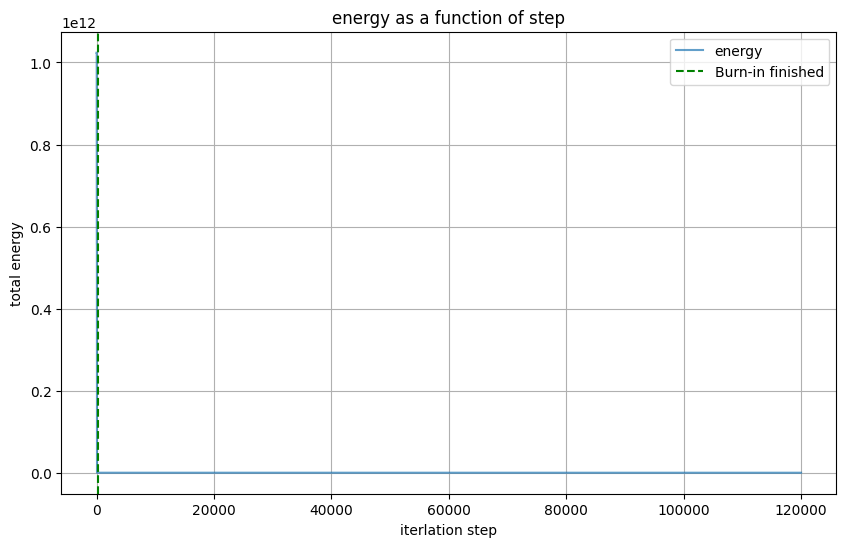

In [9]:
# ====================== 运行 ======================
if __name__ == "__main__":
    np.random.seed(42)
    
    samples, energy_history, final_config = metropolis_hastings_lj_pbc(
        N_particles=100,
        n_samples=100000,
        burn_in=20000,
        T=0.85,
        move_scale=0.28,
        box_length=5.0
    )
    
    # 绘制能量收敛曲线
    plot_energy_convergence(energy_history, burn_in=200)
    

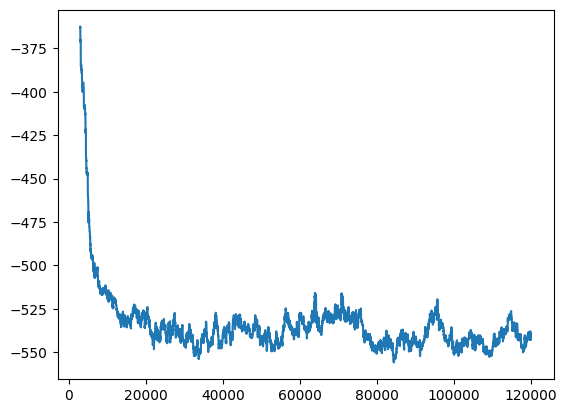

In [16]:
l=len(energy_history)
plt.plot(np.arange(l)[3000:],energy_history[3000:])